**Course name:** *Introduction to Machine Learning*  
**Spring 2025**  
**Course code:** 822047-B-6  
**Academic Year:** 2024–2025  

**Instructors:**  
Çiçek Güven  
Görkem Saygılı  
Department of Cognitive Science and Artificial Intelligence  

**Take-home Assignment 2**  
**Student:** Aiden Ricksen  
**Student number:** 2117510


Importing al the modules:

In [3]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

In [4]:
# Loads the dataset, inspect its shape, and separate into features (X) and target (y) 
data = pd.read_csv("bots_vs_users.csv")
print(data.head())
print(data.count())

X = data.drop("target", axis=1)
y = data["target"]

  has_domain has_birth_date has_photo can_post_on_wall can_send_message  \
0        1.0            1.0       0.0              0.0              0.0   
1        1.0            1.0       0.0              0.0              0.0   
2        1.0            1.0       0.0              0.0              0.0   
3        1.0            1.0       0.0              0.0              0.0   
4        1.0            1.0       0.0              0.0              0.0   

  has_website gender has_short_name has_first_name has_last_name  ...  \
0         0.0    1.0            1.0            1.0           1.0  ...   
1         0.0    1.0            1.0            1.0           1.0  ...   
2         0.0    1.0            1.0            1.0           1.0  ...   
3         0.0    1.0            1.0            1.0           1.0  ...   
4         0.0    1.0            1.0            1.0           1.0  ...   

  ads_ratio avg_views  posting_frequency_days phone_numbers_ratio  \
0       NaN       NaN                    

In [5]:
#Identify and list numerical vs. categorical features by their dtypes, then print counts and column names for each group
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numerical ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical ({len(categorical_cols)}):", categorical_cols)


Numerical (14): ['posts_count', 'avg_likes', 'links_ratio', 'hashtags_ratio', 'avg_keywords', 'avg_text_length', 'attachments_ratio', 'avg_comments', 'reposts_ratio', 'ads_ratio', 'avg_views', 'posting_frequency_days', 'phone_numbers_ratio', 'avg_text_uniqueness']
Categorical (45): ['has_domain', 'has_birth_date', 'has_photo', 'can_post_on_wall', 'can_send_message', 'has_website', 'gender', 'has_short_name', 'has_first_name', 'has_last_name', 'access_to_closed_profile', 'is_profile_closed', 'has_nickname', 'has_maiden_name', 'has_mobile', 'all_posts_visible', 'audio_available', 'has_interests', 'has_books', 'has_tv', 'has_quotes', 'has_about', 'has_games', 'has_movies', 'has_activities', 'has_music', 'can_add_as_friend', 'can_invite_to_group', 'subscribers_count', 'is_blacklisted', 'has_career', 'has_military_service', 'has_hometown', 'marital_status', 'has_universities', 'has_schools', 'has_relatives', 'is_verified', 'is_confirmed', 'has_status', 'city', 'has_occupation', 'occupation_

In [6]:
#Numeric pipeline: median‐impute + missing‐indicator, then standardize
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])


In [7]:
#Categorical pipeline: fill NaNs with "Unknown", then one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


In [8]:
#Full preprocessor: apply numeric pipeline to numeric_cols and categorical pipeline to categorical_cols
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])


In [9]:
#3-way split: first reserve 20% of X/y for final test, then from the remaining 80% reserve 20% (i.e. 16% total) for validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.20,      
    random_state=42,
    stratify=y_temp
)

print("Train / Val / Test sizes:", 
      X_train.shape[0], X_val.shape[0], X_test.shape[0])



Train / Val / Test sizes: 3759 940 1175


In [10]:
#Combine training + validation sets, then fit final Logistic Regression and Random Forest models with the best-found hyperparameters
best_rf_score  = -1
best_rf_params = None

for n in [100, 200]:
    for d in [None, 10, 20]:
        for leaf in [1, 5]:
            rf_candidate = Pipeline([
                ("preprocessor", preprocessor),
                ("classifier", RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    random_state=42
                ))
            ])
            rf_candidate.fit(X_train, y_train)
            
            y_val_pred = rf_candidate.predict(X_val)
            score = f1_score(y_val, y_val_pred)
            
            if score > best_rf_score:
                best_rf_score  = score
                best_rf_params = {
                    "n_estimators":     n,
                    "max_depth":        d,
                    "min_samples_leaf": leaf
                }

print("Best RF on VAL:", best_rf_params, "→ F1 =", best_rf_score)


Best RF on VAL: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} → F1 = 0.9808510638297873


In [11]:
#Same as the previous code block but for the logistic regression model 
best_lr_score  = -1
best_lr_params = None

for C in [0.01, 0.1, 1, 10, 100, 1000]:
    lr_candidate = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="liblinear", C=C, random_state=42
        ))
    ])
    lr_candidate.fit(X_train, y_train)
    
    y_val_pred = lr_candidate.predict(X_val)
    score = f1_score(y_val, y_val_pred)
    
    if score > best_lr_score:
        best_lr_score  = score
        best_lr_params = {"C": C}

print("Best LR on VAL:", best_lr_params, "→ F1 =", best_lr_score)


Best LR on VAL: {'C': 10} → F1 = 0.9745762711864406


In [12]:
#Retrain final models on combined Train+Val data using the best-found hyperparameters
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        **best_lr_params,
        random_state=42
    ))
]).fit(X_trainval, y_trainval)

final_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        **best_rf_params
    ))
]).fit(X_trainval, y_trainval)


In [13]:
#Generate predictions and probability estimates on the hold-out Test set for both models
y_pred_lr_test   = final_lr.predict(X_test)
y_proba_lr_test  = final_lr.predict_proba(X_test)[:,1]
y_pred_rf_test   = final_rf.predict(X_test)
y_proba_rf_test  = final_rf.predict_proba(X_test)[:,1]


In [14]:
#Shows the metrics of the two models
for name, model in [("Logistic Regression", final_lr),
                    ("Random Forest",     final_rf)]:
    y_test_pred  = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:,1]
    print(f"{name}:")
    print(f"  Accuracy : {accuracy_score(y_test,  y_test_pred):.3f}")
    print(f"  Precision: {precision_score(y_test, y_test_pred):.3f}")
    print(f"  Recall   : {recall_score(y_test,    y_test_pred):.3f}")
    print(f"  F1-score : {f1_score(y_test,      y_test_pred):.3f}")
    print(f"  AUC      : {roc_auc_score(y_test, y_test_proba):.3f}\n")


Logistic Regression:
  Accuracy : 0.969
  Precision: 0.977
  Recall   : 0.959
  F1-score : 0.968
  AUC      : 0.994

Random Forest:
  Accuracy : 0.969
  Precision: 0.984
  Recall   : 0.954
  F1-score : 0.969
  AUC      : 0.987



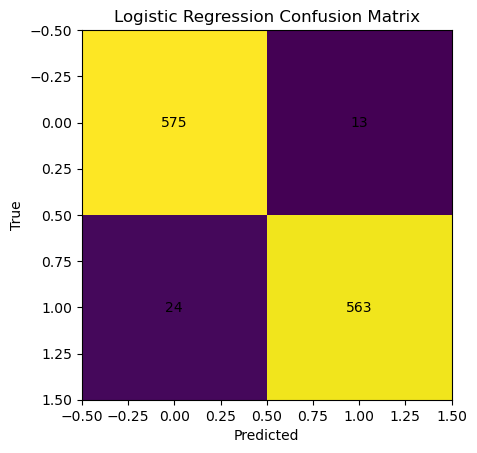

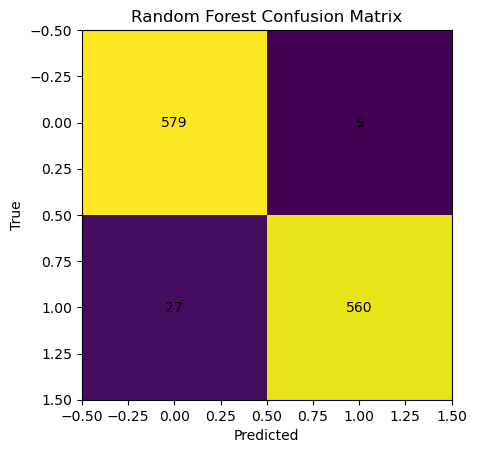

In [15]:
#Shows the confusion matrices of the two models
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
cm_rf = confusion_matrix(y_test, y_pred_rf_test)

plt.figure()
plt.imshow(cm_lr, interpolation="nearest")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")
plt.show()


plt.figure()
plt.imshow(cm_rf, interpolation="nearest")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")
plt.show()


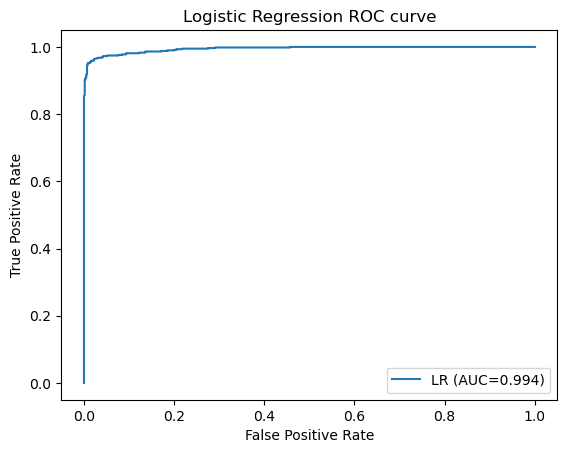

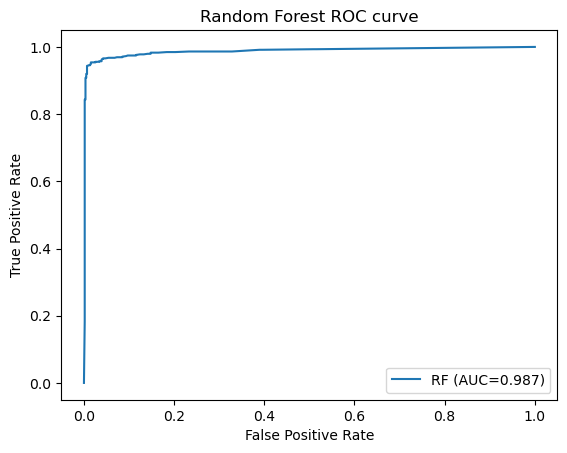

In [16]:
#Shows the ROC curve for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_test)
plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, y_proba_lr_test):.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC curve")
plt.legend()
plt.show()


fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_test)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, y_proba_rf_test):.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC curve")
plt.legend()
plt.show()


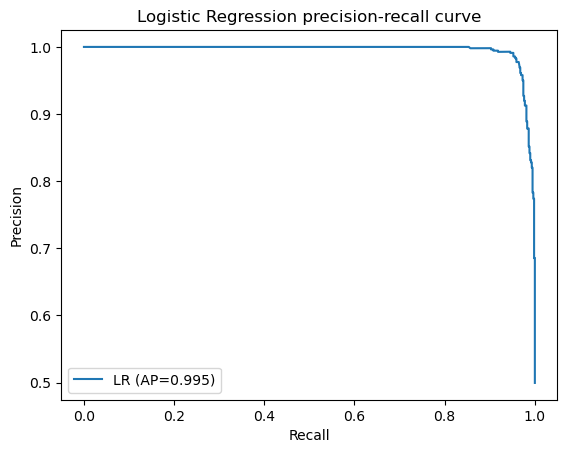

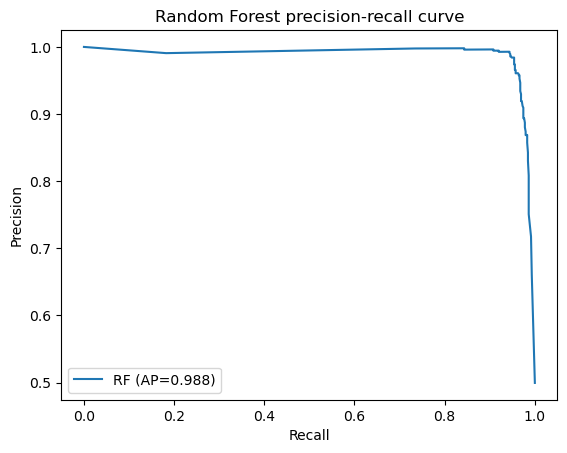

In [17]:
#Shows the precision-recall curve of both models
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr_test)
plt.figure()
plt.plot(rec_lr, prec_lr, label=f"LR (AP={average_precision_score(y_test, y_proba_lr_test):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression precision-recall curve")
plt.legend()
plt.show()


prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf_test)
plt.figure()
plt.plot(rec_rf, prec_rf, label=f"RF (AP={average_precision_score(y_test, y_proba_rf_test):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest precision-recall curve")
plt.legend()
plt.show()


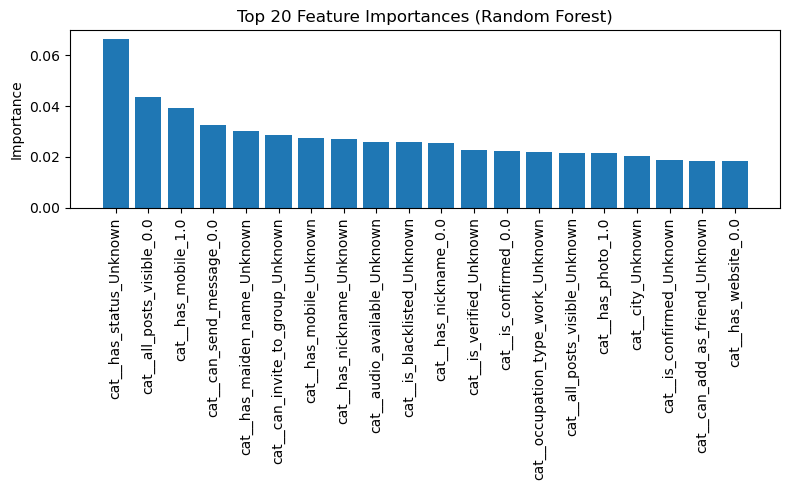

In [18]:
#Shows the top 20 feature importances from the final Random Forest model
feat_names  = final_rf.named_steps["preprocessor"].get_feature_names_out()
importances = final_rf.named_steps["classifier"].feature_importances_

idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8,5))
plt.bar(feat_names[idx], importances[idx])
plt.xticks(rotation=90)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


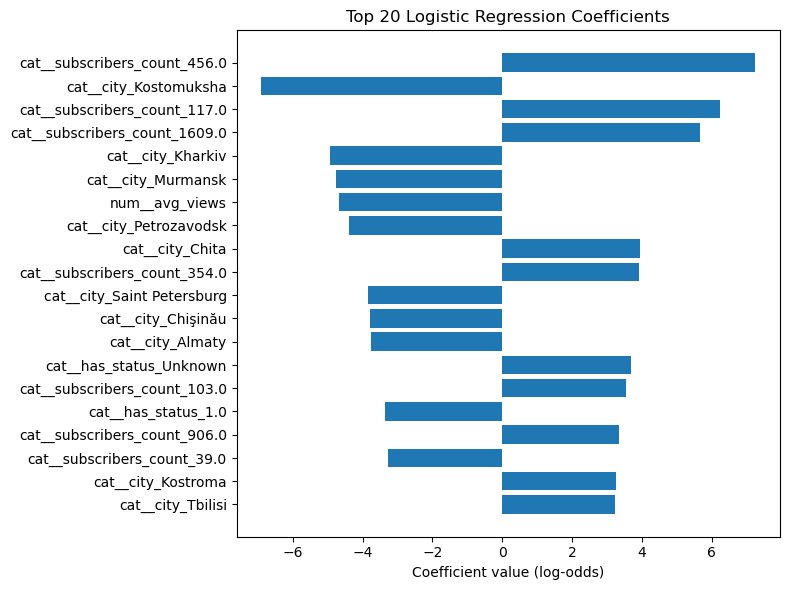

In [19]:
#Shows the top 20 logistic regression coefficients
feat_names = final_lr.named_steps["preprocessor"].get_feature_names_out()
coefs      = final_lr.named_steps["classifier"].coef_[0]

data_coefs = (
    pd.DataFrame({
        "feature": feat_names,
        "coef":    coefs,
        "abs":     np.abs(coefs)
    })
    .sort_values("abs", ascending=False)
    .head(20)
)

plt.figure(figsize=(8, 6))
plt.barh(data_coefs["feature"], data_coefs["coef"])
plt.gca().invert_yaxis()  
plt.xlabel("Coefficient value (log-odds)")
plt.title("Top 20 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

100%|===================| 999/1000 [01:00<00:00]        

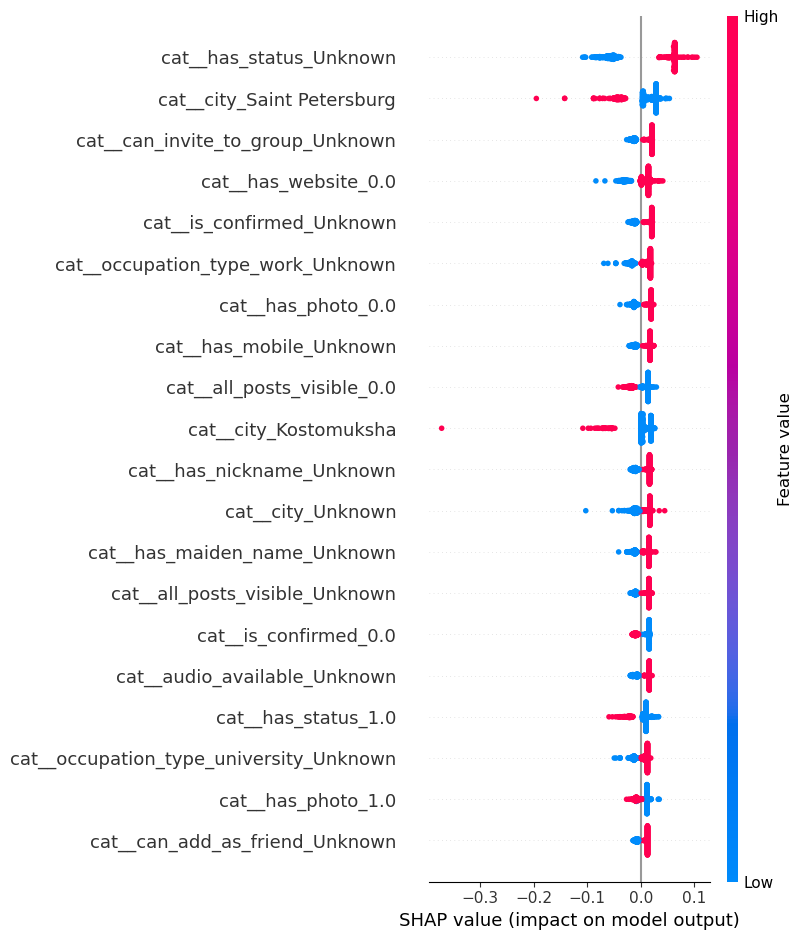

In [20]:
#Compute and shows the SHAP summary for the final Random Forest model
X_trainval_transformed = final_rf.named_steps["preprocessor"].transform(X_trainval)

sample_indices = np.random.choice(
    X_trainval_transformed.shape[0],
    size=500,
    replace=False
)
X_background = X_trainval_transformed[sample_indices, :]

shap_explainer = shap.Explainer(
    final_rf.named_steps["classifier"],
    masker=X_trainval_transformed
)

shap_values = shap_explainer(X_background)

shap.summary_plot(
    shap_values[:, :, 1],
    X_background,
    feature_names=feat_names,
    max_display=20
)


In [21]:
#Shows the error disparities across the gender variable

gendertest = pd.DataFrame({
    "gender": X_test["gender"],
    "y_true": y_test,
    "y_pred": final_rf.predict(X_test)
})

metrics = []
for g in gendertest.gender.unique():
    sub = gendertest[gendertest.gender == g]
    metrics.append({
      "gender":    g,
      "accuracy":  accuracy_score(sub.y_true, sub.y_pred),
      "precision": precision_score(sub.y_true, sub.y_pred, zero_division=0),
      "recall":    recall_score(sub.y_true, sub.y_pred, zero_division=0),
      "f1_score":  f1_score(sub.y_true, sub.y_pred, zero_division=0),
      "support":   len(sub)
    })

pd.DataFrame(metrics).set_index("gender")


,accuracy,precision,recall,f1_score,support
gender,,,,,
2.0,0.953237,0.960000,0.953642,0.956811,278
1.0,0.975225,0.992718,0.955607,0.973810,888
Unknown,0.500000,0.000000,0.000000,0.000000,2
0.0,1.000000,1.000000,1.000000,1.000000,7
